In [2]:
#we are NOT running petitRADTRANS in this tutorial however, starships needs it to run. 
#we are tricking the container here to believe we have petitRADTRANS when infact all the functions are empty

import sys
import types

# Top-level dummy package
petitRADTRANS = types.ModuleType("petitRADTRANS")

# Submodules as separate mock modules/namespaces
petitRADTRANS.Radtrans = object  # or define a dummy class

petitRADTRANS.nat_cst = types.SimpleNamespace()
petitRADTRANS.physics = types.SimpleNamespace(
    guillot_global=lambda *a, **k: None,
    guillot_modif=lambda *a, **k: None
)
petitRADTRANS._read_opacities = types.SimpleNamespace()
petitRADTRANS.fort_input = types.SimpleNamespace()
petitRADTRANS.fort_rebin = types.SimpleNamespace()
petitRADTRANS.pyth_input = types.SimpleNamespace()

poor_mans_nonequ_chem = types.ModuleType("poor_mans_nonequ_chem")
poor_mans_nonequ_chem.interpol_abundances = lambda *a, **k: None

# Register everything in sys.modules
sys.modules["petitRADTRANS"] = petitRADTRANS
sys.modules["petitRADTRANS.radtrans"] = petitRADTRANS
sys.modules["petitRADTRANS._read_opacities"] = petitRADTRANS._read_opacities
sys.modules["petitRADTRANS.fort_input"] = petitRADTRANS.fort_input
sys.modules["petitRADTRANS.fort_rebin"] = petitRADTRANS.fort_rebin
sys.modules["petitRADTRANS.pyth_input"] = petitRADTRANS.pyth_input
sys.modules["petitRADTRANS.nat_cst"] = petitRADTRANS.nat_cst
sys.modules["petitRADTRANS.physics"] = petitRADTRANS.physics
sys.modules["petitRADTRANS.poor_mans_nonequ_chem"] = poor_mans_nonequ_chem

In [3]:
from sys import path
import os
import numpy as np

from pathlib import Path

from sys import path

import matplotlib.pyplot as plt
from importlib import reload
import starships.plotting_fcts as pf 

import astropy.units as u
import astropy.constants as const

from starships import homemade as hm
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [4]:
#import Starships Function

from starships.correlation_class import Correlations
import starships.correlation_class as cc

import starships.planet_obs as pl_obs
from starships.planet_obs import Observations,Planet
import starships.correlation as corr
from itertools import product

In [5]:
# %matplotlib notebook
%matplotlib inline
couleurs = hm.get_colors('magma', 50)[5:-2]

# Load in the reduction files

This section loads the reduction files that were generated in the previous notebook.
We'll also define the planet parameters here — make sure they match the ones used in the earlier reduction step.

In [6]:

#input planet name this will pull from exofile, so can change any parameters here

pl_name='HD 189733 b'
planet_obj=Planet(pl_name)

INFO:starships.planet_obs:Getting HD 189733 b from ExoFile


In [7]:
#give a path to the files we reduced in the previous notebook, thisis the same as your outdir in the previous notebook
reduc_dir = '/home/jovyan/data/WASP-127b_container_TEST'


In [8]:
#list the file names you would like to use here
filename_list = ['sequence_2-pc_mask_wings90']
obs_list = []

#this will run through all of the name and create an "obs_list"(a list of our observations)

for filename in filename_list:
    obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)
    obs_list.append(obs)
    
#the obs list will have all of the information from the reduction files

Transmission


# Next we Need to load in the Model
In this notebook, we aren't supposed to build the model from scratch. Instead, the model should have already been created in a previous notebook, often called something like make_a_model. That earlier notebook uses PetitRADTRANS (PRT) to generate a planetary atmosphere model and saves it to a file.

Here, we simply load that precomputed model so we can analyze it or compare it to data. This approach saves time and ensures consistent results, because generating the model with PRT can take a while and depends on many input parameters.

PetitRADTRANS is a tool for simulating the transmission or emission spectra of exoplanet atmospheres, based on properties like temperature, composition, and pressure.

Text(0.5, 1.0, 'model_NIRPS-APERO_H2O_main_iso_FeH_main_iso_CO_all_is')

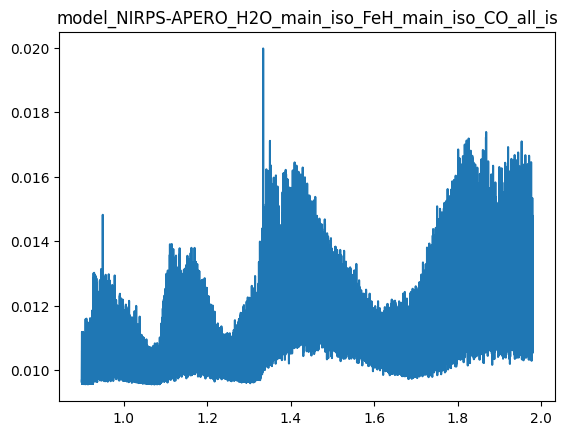

In [14]:
model_file = np.load('/home/jovyan/Models/model_NIRPS-APERO_H2O_main_iso_FeH_main_iso_CO_all_iso.npz')
wave_mod_comb, model_spec_comb = model_file['wave_mod'], model_file['mod_spec']

plt.plot(wave_mod_comb, model_spec_comb)
plt.title('model_NIRPS-APERO_H2O_main_iso_FeH_main_iso_CO_all_is')

Text(0.5, 1.0, 'model_NIRPS-APERO_H2O_pokazatel_main_iso')

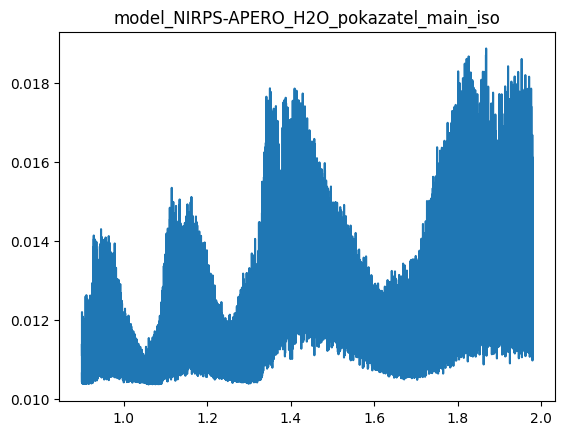

In [22]:
model_file_h20 = np.load('/home/jovyan/Models/model_NIRPS-APERO_H2O_pokazatel_main_iso.npz')
wave_mod_h20, model_spec_h20 = model_file_h20['wave_mod'], model_file['mod_spec']

plt.plot(wave_mod_h20, model_spec_h20)
plt.title('model_NIRPS-APERO_H2O_pokazatel_main_iso')

# Lets run the Injection Correlation

First we need to define a few extra parameters and then we are ready to run!

In [17]:
# define some arrays for the correlation, this is based on Spirou right now

n_RV_inj=151
corrRV0 = np.linspace(-150, 150, n_RV_inj)
Kp_array = np.array([obs.Kp.value]) 
kind_trans = 'transmission'


In [21]:
#where do you want the proucts stored?
output_dir = 'data/WASP-127b_container_TEST/'

print(output_dir)

data/WASP-127b_container_TEST/


In [23]:
#define what you want as the model for the cross correlation

wave_mod, model_spec_h20 = model_file['wave_mod'], model_file['mod_spec']


In [ ]:
model_name = 'H2O'

visit_name = 'Aug012023'
filename_list = [f'sequence_{n_pc}-pc_mask_wings{mask_w}'
                 for mask_w, n_pc in product([90], range(2, 3))]
print('\n'.join(filename_list))

n_pc_list = []
mask_wings_list = []
all_obs = dict()
all_ccf_map = dict()
all_logl_map = dict()
for filename in filename_list:
    obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)
    
    # Generate Kp 
    Kp_array = np.array([obs.Kp.value]) 
        
    n_pc = int(obs.params[5])
    n_pc_list.append(n_pc)
    
    mask_wings = int(obs.params[1] * 100)  # in percent
    mask_wings_list.append(mask_wings)
    
    out_filename = f'{Path(filename).stem}_ccf_logl_seq_{model_name}'
    
    try:
        # Check if already generated
        saved_values = np.load(output_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
    except FileNotFoundError:
        
    # Generate 1d correlations
    # ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(
            obs,'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec,  kind_trans
        )
    
    
        corr.save_logl_seq(output_dir / Path(out_filename), ccf_map, logl_map,
                            wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)


all_obs[(n_pc, mask_wings)] = obs
all_ccf_map[(n_pc, mask_wings)] = ccf_map
all_logl_map[(n_pc, mask_wings)] = logl_map

sequence_2-pc_mask_wings90
Transmission
Injecting model w/ alpha = ones
Starting with 2 PCs
Computing with
         N_pca = 2, Kp = 1/1 = 151.67, File = 1/1, RV = 27/151  

In [ ]:
#confirm that the products are all the correct shape

print(np.shape(all_logl_map))
print(all_logl_map)
print(order_indices)

# Thats it! Lets look at the results!

This can also be done in a seperate notebook

In [ ]:
# Plot single ccf and logl
n_pc, mask_wings = 2, 90

#indices you would like to include in the ccf
order_indices=[46,47]


filename = f'sequence_{n_pc}-pc_mask_wings{mask_wings}_data_trs_{visit_name}'
obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)

args = [all_something[(n_pc, mask_wings)]
        for all_something in [all_obs, all_ccf_map, all_logl_map]]

# print(args)
ccf_obj, logl_obj = cc.plot_ccflogl(*args, corrRV0, Kp_array, [n_pc], orders=order_indices)
